In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
!pip install scikit-learn

In [4]:
df = pd.read_csv("clean_jobs.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10100, 12)


,job_id,job_title,company,location,job_description,experience,education,salary,job_type,clean_description,original_length,clean_length
0,JOB07402,Frontend Developer,DataBridge Analytics,"Gurgaon, India",We are looking for a Frontend Developer to joi...,1-3 years,B.E.,9-14 LPA,Full-time,we are looking for a frontend developer to joi...,362,351
1,JOB05835,Software Engineer,Vertex Digital,"Mumbai, India",We are looking for a Software Engineer to join...,3-5 years,Bachelor's Degree,12-16 LPA,Internship,we are looking for a software engineer to join...,342,333
2,JOB02123,Machine Learning Engineer,CloudSphere,"Mumbai, India",We are looking for a Machine Learning Engineer...,1-3 years,B.E.,8-11 LPA,Full-time,we are looking for a machine learning engineer...,364,354
3,JOB08789,Cloud Engineer,Apex Solutions,"Mumbai, India",We are looking for a Cloud Engineer to join ou...,3-5 years,Master's Degree,11-16 LPA,Full-time,we are looking for a cloud engineer to join ou...,361,350
4,JOB00305,Frontend Developer,Quantix Technologies,"Noida, India",We are looking for a Frontend Developer to joi...,3-5 years,B.Tech,10-12 LPA,Full-time,we are looking for a frontend developer to joi...,366,355


In [5]:
unigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words="english",
    max_features=1000
)

unigram_matrix = unigram_vectorizer.fit_transform(
    df["clean_description"]
)

unigram_terms = unigram_vectorizer.get_feature_names_out()

print("Number of Unigrams:", len(unigram_terms))
print(unigram_terms[:50])

Number of Unigrams: 75
['analysis' 'analyst' 'analyzing' 'api' 'aws' 'azure' 'backend' 'bi'
 'business' 'candidate' 'cloud' 'collaborating' 'communication' 'cross'
 'css' 'data' 'deliverables' 'developer' 'developing' 'devops' 'docker'
 'engineer' 'excel' 'experience' 'frontend' 'functional' 'git' 'high'
 'html' 'involves' 'java' 'javascript' 'jenkins' 'jira' 'join' 'js'
 'kubernetes' 'learn' 'learning' 'linux' 'looking' 'machine' 'maintaining'
 'node' 'numpy' 'pandas' 'postgresql' 'power' 'preferred' 'problem']


In [6]:
bigram_vectorizer = TfidfVectorizer(
    ngram_range=(2, 2),
    stop_words="english",
    max_features=1000
)

bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_description"]
)

bigram_terms = bigram_vectorizer.get_feature_names_out()

print("Number of Bigrams:", len(bigram_terms))
print(bigram_terms[:50])

Number of Bigrams: 418
['analysis communication' 'analysis excel' 'analysis power'
 'analysis role' 'analysis sql' 'analysis tableau' 'analyst join'
 'analyzing requirements' 'api css' 'api docker' 'api git' 'api html'
 'api java' 'api javascript' 'api node' 'api postgresql' 'api python'
 'api react' 'api role' 'api sql' 'api testing' 'api typescript'
 'aws azure' 'aws docker' 'aws git' 'aws jenkins' 'aws kubernetes'
 'aws linux' 'aws machine' 'aws numpy' 'aws pandas' 'aws python'
 'aws pytorch' 'aws role' 'aws scikit' 'aws sql' 'aws tensorflow'
 'aws terraform' 'azure aws' 'azure docker' 'azure kubernetes'
 'azure linux' 'azure python' 'azure role' 'azure terraform'
 'backend developer' 'bi business' 'bi communication' 'bi excel'
 'bi pandas']


In [7]:
trigram_vectorizer = TfidfVectorizer(
    ngram_range=(3, 3),
    stop_words="english",
    max_features=1000
)

trigram_matrix = trigram_vectorizer.fit_transform(
    df["clean_description"]
)

trigram_terms = trigram_vectorizer.get_feature_names_out()

print("Number of Trigrams:", len(trigram_terms))
print(trigram_terms[:50])

Number of Trigrams: 1000
['analysis communication excel' 'analysis communication power'
 'analysis communication role' 'analysis communication sql'
 'analysis communication tableau' 'analysis excel communication'
 'analysis excel power' 'analysis excel role' 'analysis excel sql'
 'analysis power bi' 'analysis role involves' 'analysis sql communication'
 'analysis sql excel' 'analysis sql power' 'analysis sql role'
 'analysis sql tableau' 'analysis tableau communication'
 'analysis tableau excel' 'analysis tableau power' 'analysis tableau role'
 'analysis tableau sql' 'analyst join team'
 'analyzing requirements collaborating' 'api css git' 'api css role'
 'api docker java' 'api docker python' 'api docker role' 'api docker sql'
 'api git java' 'api git role' 'api git typescript' 'api html role'
 'api java docker' 'api java git' 'api java python' 'api java role'
 'api java sql' 'api javascript role' 'api javascript typescript'
 'api node js' 'api postgresql node' 'api postgresql role'
 '

In [8]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    stop_words="english"
)

In [9]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words="english",
    max_features=2000
)

X = vectorizer.fit_transform(
    df["clean_description"]
)

terms = vectorizer.get_feature_names_out()

print("Total Terms:", len(terms))

Total Terms: 2000


In [10]:
scores = X.sum(axis=0).A1

ngram_scores = pd.DataFrame({
    "ngram": terms,
    "score": scores
})

ngram_scores = ngram_scores.sort_values(
    by="score",
    ascending=False
)

print(ngram_scores.head(30))

                                 ngram       score
326                      communication  460.259827
324                collaborating cross  426.437128
1090                         join team  426.437128
355             cross functional teams  426.437128
1279                           looking  426.437128
1625                              role  426.437128
1626                     role involves  426.437128
1627          role involves developing  426.437128
1091               join team candidate  426.437128
285               candidate experience  426.437128
1608        requirements collaborating  426.437128
1089                              join  426.437128
390                       deliverables  426.437128
284                          candidate  426.437128
1671                            skills  426.437128
1672                  skills preferred  426.437128
1609  requirements collaborating cross  426.437128
1607                      requirements  426.437128
957      involves developing so

In [11]:
skill_phrases = [
    "machine learning",
    "deep learning",
    "natural language processing",
    "power bi",
    "data science",
    "data analysis",
    "computer vision",
    "cloud computing"
]

In [12]:
found_phrases = []

for phrase in skill_phrases:
    if phrase in set(terms):
        found_phrases.append(phrase)

print("Multi-word skills found:")
print(found_phrases)

Multi-word skills found:
['machine learning', 'power bi']


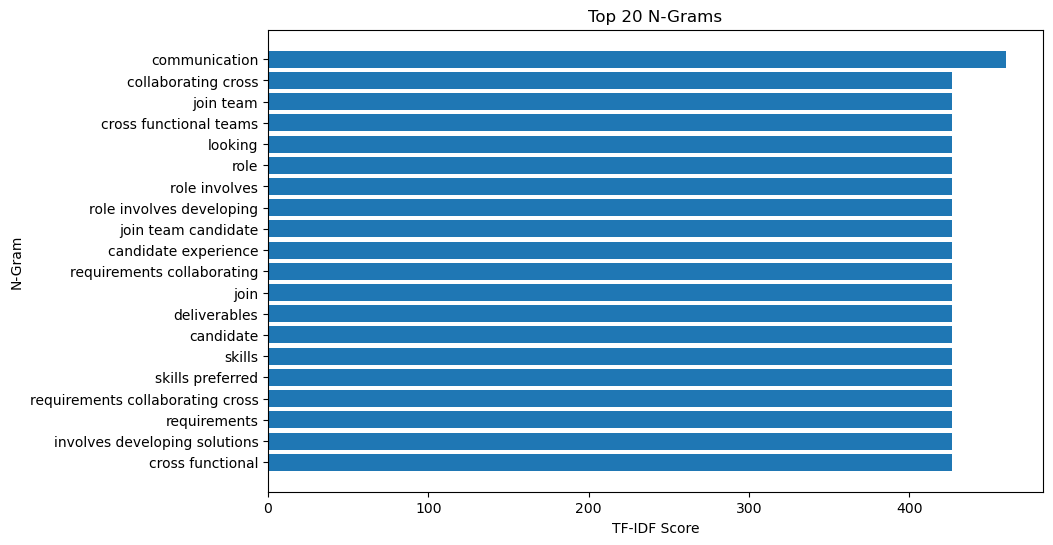

In [13]:
import matplotlib.pyplot as plt

top_ngrams = ngram_scores.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top_ngrams["ngram"],
    top_ngrams["score"]
)

plt.xlabel("TF-IDF Score")
plt.ylabel("N-Gram")
plt.title("Top 20 N-Grams")

plt.gca().invert_yaxis()

plt.show()

In [15]:
ngram_scores.to_csv(
    "ngram_results.csv",
    index=False
)

print("N-Gram results saved successfully!")

N-Gram results saved successfully!
